# Taratura del modello di scelta modale (mode-choice) — diagnostica

Domanda a cui risponde questo notebook: **la taratura car/walk/bike costruita
in `src/green_mobility/demand/mode_choice.py` è corretta, e il suo effetto
sull'OD generata e sulla simulazione è quello atteso?**

Non è una figura del paper — è uno strumento di lavoro per tarare/validare
il modello, riproducibile da zero (nessun dato letto da scratchpad).

Copertura: le 9 città già rigenerate con la nuova OD (Córdoba, Granada,
Murcia, Sevilla, A Coruña, Valladolid, Zaragoza, Bilbao, Valencia) + Palma
de Mallorca. Madrid e Barcellona non sono ancora pronte.

In [1]:
import sys, json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "configs").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT / "src"))
sys.path.insert(0, str(REPO_ROOT / "notebooks" / "paper_figures"))
sys.path.insert(0, str(REPO_ROOT / "external" / "nomad" / "python" / "preprocessing"))

from green_mobility.config import load_all_cities
from green_mobility.demand.mode_choice import ModeChoiceModel, CITY_SHIFT, BASE_COEFS
from plotting_utils import set_nature_style, MODE_COLORS

import build_od  # script NOMAD, importato in-process (non subprocess) -- sola lettura

set_nature_style()
warnings.filterwarnings("ignore", category=UserWarning)

DIAG_DIR = REPO_ROOT / "reports" / "diagnostics" / "mode_choice_calibration"
DIAG_DIR.mkdir(parents=True, exist_ok=True)

cities = load_all_cities()
CITIES_WITH_OD = ["cordoba", "granada", "murcia", "sevilla", "a_coruna",
                   "valladolid", "zaragoza", "bilbao", "valencia", "palma_de_mallorca"]
print(f"REPO_ROOT: {REPO_ROOT}")
print(f"{len(cities)} citta' configurate, {len(CITIES_WITH_OD)} con OD nuova pronta o in corso")

REPO_ROOT: /home/fbellisardi/code/green_mobility
12 citta' configurate, 10 con OD nuova pronta o in corso


## 1. Coefficienti e fonte per città

In [2]:
shift_table = pd.DataFrame([
    {"city": slug, "walk_shift": info["walk"], "bike_shift": info["bike"], "source": info["source"]}
    for slug, info in CITY_SHIFT.items()
]).set_index("city")
shift_table

,walk_shift,bike_shift,source
city,,,
cordoba,0.000000,0.000000,ESOC11 MLE diretto
granada,0.006000,-0.261800,ESOC11 MLE diretto
sevilla,-0.645900,-0.378400,ESOC11 MLE diretto
madrid,1.897347,1.897347,OMM calibrato (scalare)
barcelona,3.050928,3.050928,OMM calibrato (scalare)
valencia,1.747054,1.747054,OMM calibrato (scalare)
bilbao,2.260653,2.260653,OMM calibrato (scalare)
palma_de_mallorca,1.720664,1.720664,OMM calibrato (scalare)
zaragoza,1.701841,1.701841,OMM calibrato (scalare)


## 2. Distribuzione reale di distanza per banda (MITMA)

Serve per pesare le curve del modello sulla vera composizione di viaggi di
ogni città (non tutte le città hanno la stessa mescolanza di banda-distanza).
Calcolata una tantum dai file `viajes` grezzi (stessa logica di
`build_od.py`, nessuna reinvenzione), poi salvata in cache in
`reports/diagnostics/` — non in scratchpad, che si è già dimostrato non
persistente tra sessioni.

In [3]:
DIST_CACHE = DIAG_DIR / "city_distance_dist.csv"

def compute_city_distance_dist(cities_dict):
    od_raw = REPO_ROOT / "data" / "od_raw"
    zone_cands = list(od_raw.glob("*.gpkg")) + list(od_raw.glob("*.shp"))
    fua_file = REPO_ROOT / "data" / "fua" / "boundaries.gpkg"
    rows = []
    for slug, city in cities_dict.items():
        fua_row = build_od.find_fua(city.name, fua_file)
        fua_zones = build_od.load_mitma_zones(zone_cands[0], fua_row.geometry)
        fua_zone_ids = set(fua_zones["id"].astype(str))
        month_dir = od_raw / city.mitma_months[0]
        viajes_files = sorted(month_dir.glob("*iajes*.csv.gz")) + sorted(month_dir.glob("*iajes*.csv"))
        if not viajes_files:
            print(f"  {slug}: nessun file viajes in {month_dir}, salto")
            continue
        cols = build_od.detect_columns(viajes_files[0])
        if cols["distance"] is None:
            print(f"  {slug}: colonna distanza assente, salto")
            continue
        od = build_od.stream_viajes(viajes_files, cols, fua_zone_ids, weekend=False, holidays_set=set())
        if od is None:
            print(f"  {slug}: nessun dato feriale, salto")
            continue
        total = od[cols["trips"]].sum()
        for band, sub in od.groupby(cols["distance"]):
            share = sub[cols["trips"]].sum() / total
            if cols["km"] and sub[cols["km"]].sum() > 0:
                avg_km = float((sub[cols["km"]] / sub[cols["trips"]].replace(0, np.nan)).mean())
            else:
                avg_km = build_od.DISTANCE_BAND_FALLBACK_KM.get(band, np.nan)
            rows.append({"city": slug, "band": band, "avg_km": avg_km, "share": share})
        print(f"  {slug}: ok ({len(fua_zones)} zone MITMA, {len(viajes_files)} file)")
    return pd.DataFrame(rows)

if DIST_CACHE.exists():
    dist_df = pd.read_csv(DIST_CACHE)
    print(f"caricato da cache: {DIST_CACHE}")
else:
    print("ricalcolo distribuzione distanze per banda (una tantum)...")
    dist_df = compute_city_distance_dist(cities)
    dist_df.to_csv(DIST_CACHE, index=False)
    print(f"salvato in {DIST_CACHE}")
dist_df.head(10)

ricalcolo distribuzione distanze per banda (una tantum)...


  [20] 20220228_Viajes_distritos.csv.gz
  file usati: 20
  a_coruna: ok (25 zone MITMA, 28 file)


  [20] 20220228_Viajes_distritos.csv.gz
  file usati: 20


  barcelona: ok (240 zone MITMA, 28 file)


  [20] 20220228_Viajes_distritos.csv.gz
  file usati: 20


...

  [20] 20220228_Viajes_distritos.csv.gz
  file usati: 20


  valencia: ok (85 zone MITMA, 28 file)


  [20] 20220228_Viajes_distritos.csv.gz
  file usati: 20
  valladolid: ok (32 zone MITMA, 28 file)


  [20] 20220228_Viajes_distritos.csv.gz
  file usati: 20
  zaragoza: ok (27 zone MITMA, 28 file)
salvato in /home/fbellisardi/code/green_mobility/reports/diagnostics/mode_choice_calibration/city_distance_dist.csv


,city,band,avg_km,share
0,a_coruna,0.5-2,1.483126,0.426676
1,a_coruna,10-50,14.111190,0.074349
2,a_coruna,2-10,5.960197,0.498975
3,barcelona,0.5-2,1.461464,0.411465
4,barcelona,10-50,22.737972,0.202240
5,barcelona,2-10,6.574826,0.381052
6,barcelona,>50,58.289624,0.005242
7,bilbao,0.5-2,1.448928,0.456694
8,bilbao,10-50,17.507522,0.147134
9,bilbao,2-10,6.024968,0.396098


## 3. Target (OMM/ESOC11) vs quota auto riprodotta dal modello teorico

Per Córdoba/Granada/Sevilla lo shift viene dalla stima MLE diretta su
ESOC11 (non c'è un target separato da riprodurre — il modello *è* il fit).
Per le altre 8 lo shift è calibrato scalarmente per riprodurre il target
OMM `car/(car+piedi)`. Murcia non ha nessun target reale.

In [4]:
def p_mode(dist_km, shift):
    ld = np.log(dist_km)
    u_walk = BASE_COEFS["walk"]["const"] + BASE_COEFS["walk"]["log_dist"] * ld + shift["walk"]
    u_bike = BASE_COEFS["bike"]["const"] + BASE_COEFS["bike"]["log_dist"] * ld + shift["bike"]
    u_car = np.zeros_like(ld)
    m = np.stack([u_car, u_walk, u_bike])
    e = np.exp(m - m.max(axis=0, keepdims=True))
    p = e / e.sum(axis=0, keepdims=True)
    return p[0], p[1], p[2]

def aggregate_car_frac(city_bands, shift):
    p_car, p_walk, _ = p_mode(city_bands["avg_km"].values, shift)
    w = city_bands["share"].values
    car_w, walk_w = float((p_car * w).sum()), float((p_walk * w).sum())
    return car_w / (car_w + walk_w)

# car/(car+piedi), fonte: OMM 2025 pag.5 (gia' riverificato a 300 DPI, incluso
# il caso Palma corretto dopo l'errore di lettura riga-sbagliata)
OMM_TARGET_CAR_FRAC = {
    "madrid": 39.00 / (39.00 + 34.00), "barcelona": 19.67 / (19.67 + 48.83),
    "valencia": 41.30 / (41.30 + 41.00), "bilbao": 31.50 / (31.50 + 48.30),
    "palma_de_mallorca": 52.80 / (52.80 + 35.80), "zaragoza": 42.70 / (42.70 + 40.20),
    "valladolid": 30.00 / (30.00 + 52.90), "a_coruna": 49.21 / (49.21 + 37.34),
}

rows = []
for slug in CITY_SHIFT:
    bands = dist_df[dist_df["city"] == slug]
    if bands.empty:
        continue
    shift = CITY_SHIFT[slug]
    reproduced = aggregate_car_frac(bands, shift)
    target = OMM_TARGET_CAR_FRAC.get(slug, np.nan)
    rows.append({"city": slug, "source": shift["source"], "target_car_frac": target,
                 "reproduced_car_frac": reproduced,
                 "diff_pp": 100 * (reproduced - target) if not np.isnan(target) else np.nan})
calib_table = pd.DataFrame(rows).set_index("city")
flagged = calib_table[calib_table["diff_pp"].abs() > 2]
if len(flagged):
    print(f"ATTENZIONE: {len(flagged)} citta' con scarto >2pp dal target:")
    print(flagged)
calib_table

ATTENZIONE: 8 citta' con scarto >2pp dal target:
                                    source  target_car_frac  \
city                                                          
madrid             OMM calibrato (scalare)         0.534247   
barcelona          OMM calibrato (scalare)         0.287153   
valencia           OMM calibrato (scalare)         0.501823   
bilbao             OMM calibrato (scalare)         0.394737   
palma_de_mallorca  OMM calibrato (scalare)         0.595937   
zaragoza           OMM calibrato (scalare)         0.515078   
valladolid         OMM calibrato (scalare)         0.361882   
a_coruna           OMM calibrato (scalare)         0.568573   

                   reproduced_car_frac    diff_pp  
city                                               
madrid                        0.635454  10.120713  
barcelona                     0.418975  13.182139  
valencia                      0.600905   9.908249  
bilbao                        0.495404  10.066678  
palma_de

,source,target_car_frac,reproduced_car_frac,diff_pp
city,,,,
cordoba,ESOC11 MLE diretto,NaN,0.779391,NaN
granada,ESOC11 MLE diretto,NaN,0.873476,NaN
sevilla,ESOC11 MLE diretto,NaN,0.916457,NaN
madrid,OMM calibrato (scalare),0.534247,0.635454,10.120713
barcelona,OMM calibrato (scalare),0.287153,0.418975,13.182139
valencia,OMM calibrato (scalare),0.501823,0.600905,9.908249
bilbao,OMM calibrato (scalare),0.394737,0.495404,10.066678
palma_de_mallorca,OMM calibrato (scalare),0.595937,0.676262,8.032472
zaragoza,OMM calibrato (scalare),0.515078,0.595579,8.050036


## 4. Curve di decadimento per distanza P(mode | km)

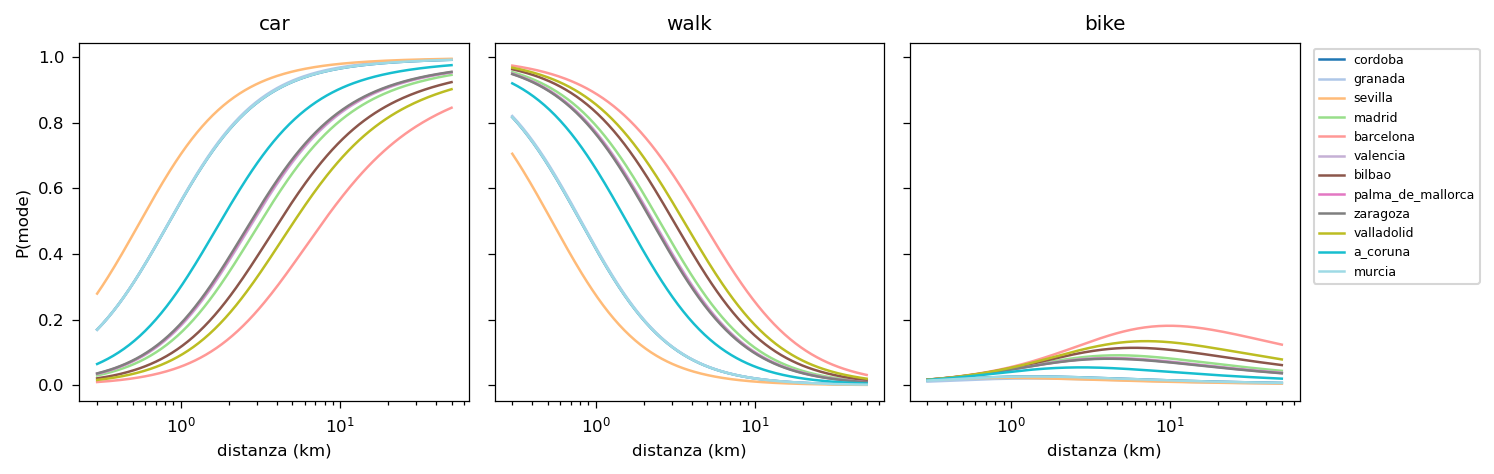

In [5]:
dist_grid = np.geomspace(0.3, 50, 200)
fig, axes = plt.subplots(1, 3, figsize=(10, 3.2), sharey=True)
cmap = plt.cm.tab20(np.linspace(0, 1, len(CITY_SHIFT)))
for ax, mode in zip(axes, ["car", "walk", "bike"]):
    ax.set_title(mode)
    ax.set_xscale("log")
    ax.set_xlabel("distanza (km)")
axes[0].set_ylabel("P(mode)")
for i, slug in enumerate(CITY_SHIFT):
    probs = ModeChoiceModel(slug).predict_proba(dist_grid)
    for ax, mode in zip(axes, ["car", "walk", "bike"]):
        ax.plot(dist_grid, probs[mode], color=cmap[i], lw=1.2, label=slug)
axes[-1].legend(fontsize=6, ncol=1, bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
plt.show()

## 5. Split modale effettivo nell'OD realmente generata vs target

Non il modello teorico — le righe vere di `od_{city}_weekday.csv`, dopo
`occupancy_factor`, fallback di banda, rumore giornaliero, ecc. Controlla
che `build_od_rows` non introduca uno scarto rispetto al modello teorico.

In [6]:
rows = []
for slug in CITIES_WITH_OD:
    path = cities[slug].od_csv("weekday")
    if not path.exists():
        print(f"{slug}: OD non ancora pronta ({path})")
        continue
    df = pd.read_csv(path, usecols=["count", "mode"])
    tot = df.groupby("mode")["count"].sum()
    tot_all = tot.sum()
    share = (tot / tot_all * 100).to_dict()
    denom = tot.get("car", 0) + tot.get("walk", 0)
    car_frac_eff = tot.get("car", 0) / denom if denom > 0 else np.nan
    rows.append({"city": slug,
                 **{f"{m}_%": round(share.get(m, 0.0), 2) for m in ["car", "walk", "bike", "transit"]},
                 "car_frac_effettivo": car_frac_eff,
                 "target_car_frac": OMM_TARGET_CAR_FRAC.get(slug, np.nan)})
od_split_table = pd.DataFrame(rows).set_index("city")
od_split_table

,car_%,walk_%,bike_%,transit_%,car_frac_effettivo,target_car_frac
city,,,,,,
cordoba,49.93,19.46,1.84,28.78,0.719589,NaN
granada,53.67,14.69,1.09,30.55,0.785097,NaN
murcia,53.07,13.55,1.67,31.70,0.796588,NaN
sevilla,59.80,9.68,1.18,29.35,0.860700,NaN
a_coruna,37.72,29.27,3.43,29.58,0.563083,0.568573
valladolid,20.14,44.52,6.89,28.44,0.311478,0.361882
zaragoza,30.12,36.81,4.87,28.20,0.450023,0.515078
bilbao,23.89,43.07,5.57,27.47,0.356834,0.394737
valencia,30.69,36.70,4.44,28.16,0.455387,0.501823


## 6. Salute della simulazione: arrival/teleport rate, OD vecchia vs nuova

Date diverse tra vecchia (2022-10-28, se non altrimenti indicato) e nuova
(2022-02-08) per 6 città — non è un confronto perfettamente pulito (la
domanda MITMA reale cambia comunque tra le due date), ma è l'unico
confronto disponibile senza rilanciare le vecchie simulazioni.
Sevilla/Bilbao avevano una baseline sulla stessa data, ma il run con OD
nuova ha scritto nello stesso path e l'ha sovrascritta — i valori vecchi
sono qui registrati manualmente (visti a schermo prima della sovrascrittura),
non più rileggibili da disco. Valencia non ha ancora una simulazione con la
OD nuova (solo l'OD è pronta).

In [7]:
def read_rate(path):
    if path is None or not path.exists():
        return None, None
    m = json.loads(path.read_text())
    return m.get("arrival_rate"), m.get("teleported_rate")

RUN_COMPARISON = {
    "cordoba":    ("results/cordoba/weekday_full_car_2022-10-28/2022-10-28_00-00_23-59.manifest.json",
                   "results/cordoba/weekday_full_car_2022-02-08/2022-02-08_00-00_23-59.manifest.json"),
    "granada":    ("results/granada/weekday_full_car_2022-10-28/2022-10-28_00-00_23-59.manifest.json",
                   "results/granada/weekday_full_car_2022-02-08/2022-02-08_00-00_23-59.manifest.json"),
    "murcia":     ("results/murcia/weekday_full_car_2022-10-28/2022-10-28_00-00_23-59.manifest.json",
                   "results/murcia/weekday_full_car_2022-02-08/2022-02-08_00-00_23-59.manifest.json"),
    "a_coruna":   ("results/a_coruna/weekday_full_car_2022-10-28/2022-10-28_00-00_23-59.manifest.json",
                   "results/a_coruna/weekday_full_car_2022-02-08/2022-02-08_00-00_23-59.manifest.json"),
    "valladolid": ("results/valladolid/weekday_full_car_2022-10-28/2022-10-28_00-00_23-59.manifest.json",
                   "results/valladolid/weekday_full_car_2022-02-08/2022-02-08_00-00_23-59.manifest.json"),
    "zaragoza":   ("results/zaragoza/weekday_full_car_2022-10-28/2022-10-28_00-00_23-59.manifest.json",
                   "results/zaragoza/weekday_full_car_2022-02-08/2022-02-08_00-00_23-59.manifest.json"),
    "sevilla":    (None, "results/sevilla/weekday_full_car_2022-02-08/2022-02-08_00-00_23-59.manifest.json"),
    "bilbao":     (None, "results/bilbao/weekday_full_car_2022-02-08/2022-02-08_00-00_23-59.manifest.json"),
    "palma_de_mallorca": ("results/palma_de_mallorca/weekday_full_car/2022-02-08_00-00_23-59.manifest.json",
                          "results/palma_de_mallorca/weekday_full_car_2022-02-08/2022-02-08_00-00_23-59.manifest.json"),
}
MANUAL_OVERWRITTEN_OLD = {
    "sevilla": {"arrival_rate": 0.928, "teleported_rate": 0.0004},
    "bilbao": {"arrival_rate": 0.9487, "teleported_rate": 0.0},
}

rows = []
for slug, (old_rel, new_rel) in RUN_COMPARISON.items():
    old_path = REPO_ROOT / old_rel if old_rel else None
    new_path = REPO_ROOT / new_rel
    old_arr, old_tel = read_rate(old_path)
    note = ""
    if old_path is None and slug in MANUAL_OVERWRITTEN_OLD:
        old_arr = MANUAL_OVERWRITTEN_OLD[slug]["arrival_rate"]
        old_tel = MANUAL_OVERWRITTEN_OLD[slug]["teleported_rate"]
        note = "OD-vecchia sovrascritta, valori registrati manualmente"
    new_arr, new_tel = read_rate(new_path)
    rows.append({"city": slug, "arrival_old": old_arr, "arrival_new": new_arr,
                 "teleport_old": old_tel, "teleport_new": new_tel, "note": note})
sim_health_table = pd.DataFrame(rows).set_index("city")
sim_health_table

,arrival_old,arrival_new,teleport_old,teleport_new,note
city,,,,,
cordoba,NaN,None,NaN,None,
granada,NaN,None,NaN,None,
murcia,NaN,None,NaN,None,
a_coruna,NaN,None,NaN,None,
valladolid,NaN,None,NaN,None,
zaragoza,NaN,None,NaN,None,
sevilla,0.9280,None,0.0004,None,"OD-vecchia sovrascritta, valori registrati man..."
bilbao,0.9487,None,0.0000,None,"OD-vecchia sovrascritta, valori registrati man..."
palma_de_mallorca,NaN,None,NaN,None,


## 7. Fundamental diagram: caso illustrativo (Zaragoza)

Stessa tecnica del pannello B della Figure 2 (binning densità→flusso
mediano, rilevazione ramo discendente), letta direttamente dai risultati
grezzi (`load_car_bins`), non serve canopy/shadow/UTCI.

In [8]:
from green_mobility.nomad_wrapper.car_snapshots import load_car_bins

ROAD_CLASS_LABELS = {0: "Motorway", 1: "MotorwayLink", 2: "Trunk", 3: "TrunkLink",
                     4: "Primary", 5: "PrimaryLink", 6: "Secondary", 7: "SecondaryLink",
                     8: "Tertiary", 9: "TertiaryLink", 10: "Residential", 11: "LivingStreet",
                     12: "Service", 13: "Unclassified"}

def binned_median_curve(density, flow, bin_width=5.0, n_thresh=50):
    upper = density.quantile(0.995)
    if not np.isfinite(upper) or upper <= 0:
        return pd.DataFrame(columns=["density_mid", "flow_median", "n"])
    bin_edges = np.arange(0, upper + bin_width, bin_width)
    d = pd.DataFrame({"density": density.values, "flow": flow.values})
    d["density_bin"] = pd.cut(d["density"], bin_edges)
    agg = d.groupby("density_bin", observed=True).agg(
        density_mid=("density", "median"), flow_median=("flow", "median"), n=("flow", "size")).dropna()
    return agg[agg["n"] >= n_thresh].sort_values("density_mid").reset_index(drop=True)

def diagnose(curve):
    if len(curve) == 0:
        return dict(has_descending_branch=False, max_flow=np.nan, density_at_max=np.nan, drop_pct=np.nan)
    idx_max = int(curve["flow_median"].idxmax())
    max_flow = float(curve.loc[idx_max, "flow_median"])
    density_at_max = float(curve.loc[idx_max, "density_mid"])
    post_peak = curve.loc[idx_max:]
    if len(post_peak) - 1 >= 2:
        drop_pct = 100 * (1 - float(post_peak["flow_median"].iloc[-1]) / max_flow)
        descending = drop_pct > 10
    else:
        drop_pct, descending = np.nan, False
    return dict(has_descending_branch=descending, max_flow=max_flow, density_at_max=density_at_max, drop_pct=drop_pct)

ZARAGOZA_RUNS = {"OD vecchia (2022-10-28)": "results/zaragoza/weekday_full_car_2022-10-28",
                 "OD nuova mode-choice (2022-02-08)": "results/zaragoza/weekday_full_car_2022-02-08"}
edges = pd.read_parquet(REPO_ROOT / "data/zaragoza/edges.parquet")[["edge_id", "length_m"]]

rows = []
for level, rel in ZARAGOZA_RUNS.items():
    out_dir = sorted((REPO_ROOT / rel).glob("2022-*"))[0]
    bins = load_car_bins(out_dir, occupancy_factor=1.20)
    m = bins.merge(edges, on="edge_id", how="left")
    m["density_raw"] = m["occupancy_veh"] / (m["length_m"] / 1000.0)
    m["flow_raw"] = np.where(m["mean_travel_time_s"] > 0,
                              m["occupancy_veh"] * 3600.0 / m["mean_travel_time_s"], np.nan)
    m = m.dropna(subset=["flow_raw"])
    n_descending, details = 0, []
    for rc in sorted(m["road_class"].unique()):
        diag = diagnose(binned_median_curve(m.loc[m["road_class"] == rc, "density_raw"],
                                             m.loc[m["road_class"] == rc, "flow_raw"]))
        if diag["has_descending_branch"]:
            n_descending += 1
            details.append(f"{ROAD_CLASS_LABELS.get(int(rc), rc)} (calo {diag['drop_pct']:.0f}%)")
    rows.append({"run": level, "occupancy_veh_tot": int(m["occupancy_veh"].sum()),
                 "n_classi_ramo_discendente": n_descending, "classi": "; ".join(details)})
pd.DataFrame(rows).set_index("run")

,occupancy_veh_tot,n_classi_ramo_discendente,classi
run,,,
OD vecchia (2022-10-28),2138992,2,Trunk (calo 26%); Residential (calo 22%)
OD nuova mode-choice (2022-02-08),2255909,1,Trunk (calo 20%)


## Limiti noti (dichiarati esplicitamente, non nascosti)

- **Murcia**: nessun target reale (non in OMM, non in ESOC11/Andalucia) —
  shift=0, modello pooled, bassa confidenza dichiarata nel codice stesso.
- **Forma della curva "presa in prestito"**: per le 8 città calibrate su OMM,
  solo il livello aggregato (quota auto cittadina) è garantito dalla
  calibrazione — la *forma* del decadimento per distanza viene da ESOC11
  (Andalusia) e non è stata validata indipendentemente a distanze brevi per
  quelle 8 città.
- **Córdoba**: il 44.7% auto stimato da ESOC11 resta a fonte singola — non
  c'è un riscontro OMM (Córdoba non è coperta) né una percentuale aggregata
  nel piano di trasporto metropolitano (che ha solo le formule del modello
  di scelta, non un dato di sintesi).
- **Confronto arrival/teleport rate**: per 6 città confronta date diverse
  (2022-10-28 vecchia vs 2022-02-08 nuova) — non isola perfettamente
  l'effetto della sola nuova OD dalla variazione di domanda reale tra le
  due date. Per Sevilla/Bilbao la baseline vecchia sulla stessa data è
  stata sovrascritta (valori solo registrati a mano).
- **Caso Palma**: la lettura iniziale del grafico OMM conteneva un errore
  di riga (Asturias invece di Majorca), corretto dopo una verifica
  dell'utente — vedi commit history di `mode_choice.py` per i valori
  esatti prima/dopo. Promemoria a non fidarsi ciecamente di letture di
  grafici impilati senza un secondo controllo.